# **5. Rotary Kilns**

Rotary kilns are treated differently from the other four equipment types in this
framework. For agitated tanks, mixers, filtration units and dryers, installed motor
power intensity scales with capacity and the deliverable is a fitted power law. For
rotary kilns it does not: the drum-drive power intensity is size independent over the
compiled range, and the deliverable is a single constant expressed as a geometric mean
in log space.

The workflow below therefore differs from the other notebooks in two respects:

1. **Outlier screening** uses the 1.5 x IQR rule applied to log(P/V).
   Regression-based influence measures (leverage, externally studentized residuals,
   DFFITS, Cook's distance) are not used, because there is no fitted regression
   whose influence they would measure.
2. **Model selection** is framed as a test for the *absence* of scaling. Constant,
   linear, quadratic and cubic models in log space are compared by nested F-test,
   AIC and BIC, and the linear slope is tested against zero with an HC3-robust
   standard error. The constant model is reported.

In [1]:
### Import all that is required ###

import numpy as np
import pandas as pd
import math

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from scipy import stats
from scipy.stats import t

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

In [2]:
### Setting global plot features ###

plt.style.use("default")

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Liberation Serif", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 11,
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "axes.labelsize": 11,
    "axes.labelcolor": "black",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "text.color": "black",
    "figure.facecolor": "white",
    "figure.dpi": 150,
    "legend.frameon": True,
    "legend.framealpha": 1.0,
    "legend.edgecolor": "#cccccc",
    "legend.fontsize": 9,
    "lines.linewidth": 1.8,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
})

OBS_COLOR        = "#1B3A5C"   # navy    - retained observations
REMOVED_PT_COLOR = "#A0293D"   # red     - excluded observations
FIT_LINE_COLOR   = "#B03A2E"   # dark red - constant / fitted line
RMSE_BAND_COLOR  = "#64A082"   # sage    - dispersion band
GM_MARKER_COLOR  = "#B07D2A"   # amber   - geometric mean marker
REF_LINE_COLOR   = "#B07D2A"   # amber   - reference and threshold lines

In [3]:
### Defining required functions ###

def freedman_diaconis_bins(data):
    """Number of histogram bins by the Freedman-Diaconis rule."""
    data = np.asarray(data)
    q25, q75 = np.percentile(data, [25, 75])
    iqr = q75 - q25
    bin_width = 2 * iqr / (data.size ** (1 / 3))
    if bin_width == 0:
        return 1
    return int(np.ceil((data.max() - data.min()) / bin_width))


def distribution_kolmogorov_smirnov_tests(data):
    """Fit candidate distributions by MLE and rank them by K-S p-value."""
    distributions = {"lognorm": "Log-normal", "norm": "Normal",
                     "triang": "Triangular", "uniform": "Uniform"}
    results = []
    for key, label in distributions.items():
        dist = getattr(stats, key)
        params = dist.fit(data)
        ks, p = stats.kstest(data, key, args=params)
        results.append((label, ks, p))
    out = pd.DataFrame(results, columns=["Distribution", "KS Statistic", "p-value"])
    out["KS Statistic"] = out["KS Statistic"].round(4)
    return out.sort_values("p-value", ascending=False).reset_index(drop=True)


def iqr_fences(series, k=1.5):
    """Lower and upper Tukey fences of a series."""
    q1, q3 = np.percentile(series, [25, 75])
    iqr = q3 - q1
    return q1, q3, iqr, q1 - k * iqr, q3 + k * iqr


def flag_log_space_outliers(df, log_cols, k=1.5):
    """Flag rows falling outside the 1.5 x IQR fences of any listed log-space column.

    Returns the boolean mask and a per-column table of quartiles and fences.
    """
    mask = np.zeros(len(df), dtype=bool)
    rows = []
    for col in log_cols:
        q1, q3, iqr, lo, hi = iqr_fences(df[col].values, k=k)
        col_mask = (df[col].values < lo) | (df[col].values > hi)
        mask |= col_mask
        rows.append({"Variable": col, "Q1": round(q1, 4), "Q3": round(q3, 4),
                     "IQR": round(iqr, 4), "Lower fence": round(lo, 4),
                     "Upper fence": round(hi, 4), "Flagged (n)": int(col_mask.sum())})
    return mask, pd.DataFrame(rows)


def nested_polynomial_comparison(x, y, max_degree=3):
    """Compare constant through degree-`max_degree` polynomials in log space.

    Reports R2, adjusted R2, RMSE, AIC and BIC for each order, plus the nested
    F-test of each order against the next lower order. Coefficient-level
    eligibility is assessed separately, in `polynomial_coefficient_table`.
    """
    fits = {}
    for d in range(0, max_degree + 1):
        X = np.vander(x, d + 1, increasing=True)
        fits[d] = sm.OLS(y, X).fit()
    rows = []
    for d, m in fits.items():
        row = {"Degree": d,
               "k (params)": int(m.df_model + 1),
               "R2": round(m.rsquared, 4),
               "R2_adj": round(m.rsquared_adj, 4),
               "RMSE": round(float(np.sqrt(np.mean(m.resid ** 2))), 4),
               "AIC": round(m.aic, 2),
               "BIC": round(m.bic, 2)}
        if d == 0:
            row["F vs degree-1 lower"] = np.nan
            row["p (nested F)"] = np.nan
        else:
            m0, m1 = fits[d - 1], m
            num = (m0.ssr - m1.ssr) / (m0.df_resid - m1.df_resid)
            den = m1.ssr / m1.df_resid
            f = num / den
            row["F vs degree-1 lower"] = round(float(f), 4)
            row["p (nested F)"] = round(float(stats.f.sf(f, m0.df_resid - m1.df_resid,
                                                        m1.df_resid)), 4)
        rows.append(row)
    return pd.DataFrame(rows), fits


def constant_model_summary(values, label):
    """Geometric mean, dispersion, confidence and prediction intervals in log10 space.

    `values` are on the original (non-log) scale. `s` is the standard deviation of
    log10(values) and is the dispersion symbol used throughout the manuscript.
    """
    v = np.asarray(values, dtype=float)
    v = v[v > 0]
    lg = np.log10(v)
    n = len(lg)
    mean_lg = lg.mean()
    s = lg.std(ddof=1)
    gm = 10 ** mean_lg
    gsd = 10 ** s
    se = s / np.sqrt(n)
    t_crit = t.ppf(0.975, df=n - 1)
    z = stats.norm.ppf(0.975)
    smear = float(np.exp((np.log(10) ** 2) * s ** 2 / 2))
    return pd.DataFrame([{
        "Equipment": label,
        "n": n,
        "Geometric mean": round(gm, 4),
        "s (log10)": round(s, 4),
        "GSD": round(gsd, 4),
        "95% CI for GM": f"[{10 ** (mean_lg - t_crit * se):.4f}, "
                         f"{10 ** (mean_lg + t_crit * se):.4f}]",
        "95% prediction interval": f"[{gm / 10 ** (z * s):.4f}, {gm * 10 ** (z * s):.4f}]",
        "Smearing factor": round(smear, 4),
    }])


def polynomial_coefficient_table(x, y, device, degrees=(1, 2, 3)):
    """Coefficients, t-statistics, p-values and 95% CIs for each polynomial order.

    Matches the `df_coefs` output used to build SI Table S3 for the other
    equipment types, with two added columns: whether each coefficient's 95%
    confidence interval contains zero, and whether the order as a whole is
    eligible for selection (no coefficient consistent with zero).
    """
    rows = []
    for deg in degrees:
        X = np.vander(x, deg + 1, increasing=True)
        m = sm.OLS(y, X).fit()
        ci = m.conf_int()
        eligible = not any(ci[k, 0] <= 0 <= ci[k, 1] for k in range(deg + 1))
        for i, coef in enumerate(m.params):
            rows.append({
                "Device": device,
                "Degree": deg,
                "Term": "Intercept" if i == 0 else f"x^{i}",
                "Coefficient": coef,
                "T-stat": m.tvalues[i],
                "p-value": m.pvalues[i],
                "CI lower": ci[i, 0],
                "CI upper": ci[i, 1],
                "CI contains zero": bool(ci[i, 0] <= 0 <= ci[i, 1]),
                "Eligible": eligible,
            })
    return pd.DataFrame(rows)

## ***5.0. Rotary Kilns: Data***

In [4]:
file_path  = "Equipment Capacity Power Type Input File.xlsx"
sheet_name = "Rotary Kilns"

df = pd.read_excel(file_path, sheet_name=sheet_name)

rotary_kilns_entry_no = df["Entry No."].tolist()
rotary_kilns_volume_m3 = df["Volumetric Capacity, m3"].astype(float).tolist()
rotary_kilns_power_kw = df["Motor Power, kW"].astype(float).tolist()
rotary_kilns_subtype = df["Rotary Kiln Subtype"].astype(str).tolist()

rotary_kilns_raw_unsorted = pd.DataFrame({
    "Entry_No.": rotary_kilns_entry_no,
    "Volume_m³": rotary_kilns_volume_m3,
    "Power_kW":  rotary_kilns_power_kw,
    "Subtype":   rotary_kilns_subtype,
})

rotary_kilns_raw_unsorted["PowerToCapacity_kW·m⁻³"] = (
    rotary_kilns_raw_unsorted["Power_kW"] / rotary_kilns_raw_unsorted["Volume_m³"]
)
rotary_kilns_raw_unsorted["log(Capacity)"] = np.log10(
    rotary_kilns_raw_unsorted["Volume_m³"]
)
rotary_kilns_raw_unsorted["log(PowerToCapacity)"] = np.log10(
    rotary_kilns_raw_unsorted["PowerToCapacity_kW·m⁻³"]
)

rotary_kilns_raw = (rotary_kilns_raw_unsorted
                    .sort_values(by="Volume_m³")
                    .reset_index(drop=True))
rotary_kilns_raw.insert(0, "Capacity Sorted No.", rotary_kilns_raw.index + 1)

print(f"Records      : {len(rotary_kilns_raw)}")
print(f"Subtypes     : {sorted(rotary_kilns_raw['Subtype'].unique())}")
print(f"Volume range : {rotary_kilns_raw['Volume_m³'].min():.2f} – "
      f"{rotary_kilns_raw['Volume_m³'].max():.2f} m³")
rotary_kilns_raw.head()

Records      : 120
Subtypes     : ['Rotary Kiln']
Volume range : 7.54 – 2732.21 m³


,Capacity Sorted No.,Entry_No.,Volume_m³,Power_kW,Subtype,PowerToCapacity_kW·m⁻³,log(Capacity),log(PowerToCapacity)
0,1,44,7.54,5.50,Rotary Kiln,0.729443,0.877371,-0.137009
1,2,1,21.87,0.75,Rotary Kiln,0.034294,1.339849,-1.464788
2,3,112,28.28,22.00,Rotary Kiln,0.777935,1.451479,-0.109057
3,4,40,45.95,22.00,Rotary Kiln,0.478781,1.662286,-0.319863
4,5,41,61.08,30.00,Rotary Kiln,0.491159,1.785899,-0.308778


## ***5.1. Rotary Kilns: Pre-Analysis Data Diagnostics***

### ***5.1.1 Distributional Check***

generating Figure S1e


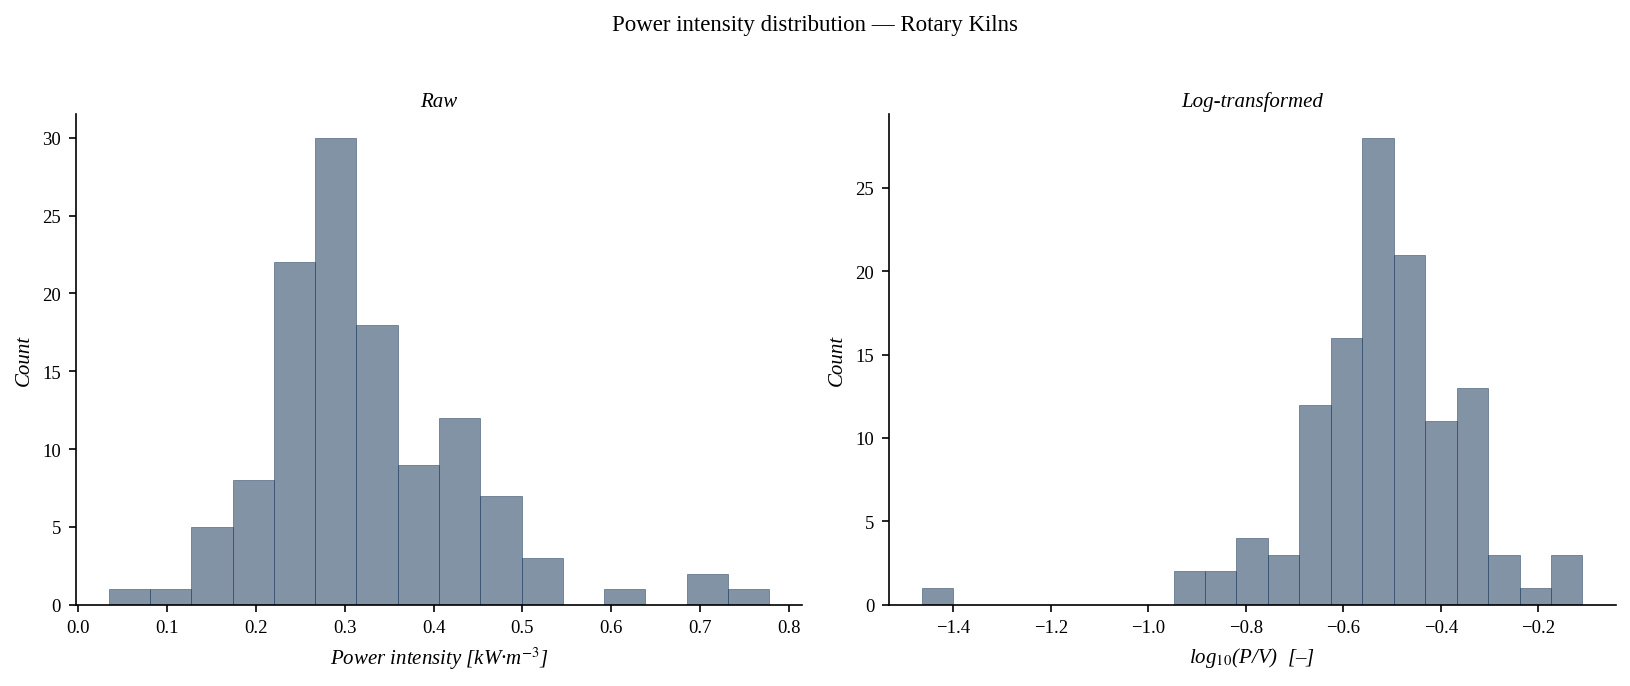

In [5]:
print("generating Figure S1e")
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, col, xlabel, title in zip(
        axes,
        ["PowerToCapacity_kW·m⁻³", "log(PowerToCapacity)"],
        ["Power intensity [kW·m$^{-3}$]", "log$_{10}$(P/V)  [–]"],
        ["Raw", "Log-transformed"]):
    data = rotary_kilns_raw[col].dropna()
    ax.hist(data, bins=freedman_diaconis_bins(data), color=OBS_COLOR,
            alpha=0.55, edgecolor=OBS_COLOR, linewidth=0.4)
    ax.set_xlabel(xlabel, style="italic", fontsize=10)
    ax.set_ylabel("Count", style="italic", fontsize=10)
    ax.set_title(title, fontsize=10, style="italic", pad=4)

fig.suptitle("Power intensity distribution — Rotary Kilns", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

In [6]:
distributions_results_rk = distribution_kolmogorov_smirnov_tests(
    rotary_kilns_raw["PowerToCapacity_kW·m⁻³"]
)
print("generating Table S1")
print("Kolmogorov–Smirnov goodness-of-fit, rotary kiln power intensity:")
distributions_results_rk

generating Table S1
Kolmogorov–Smirnov goodness-of-fit, rotary kiln power intensity:


,Distribution,KS Statistic,p-value
0,Log-normal,0.0652,6.624775e-01
1,Normal,0.1074,1.165139e-01
2,Triangular,0.1953,1.747102e-04
3,Uniform,0.3273,5.983068e-12


### ***5.1.2 Power–Capacity Trend Across Rotary Kilns***

generating Figure S2e


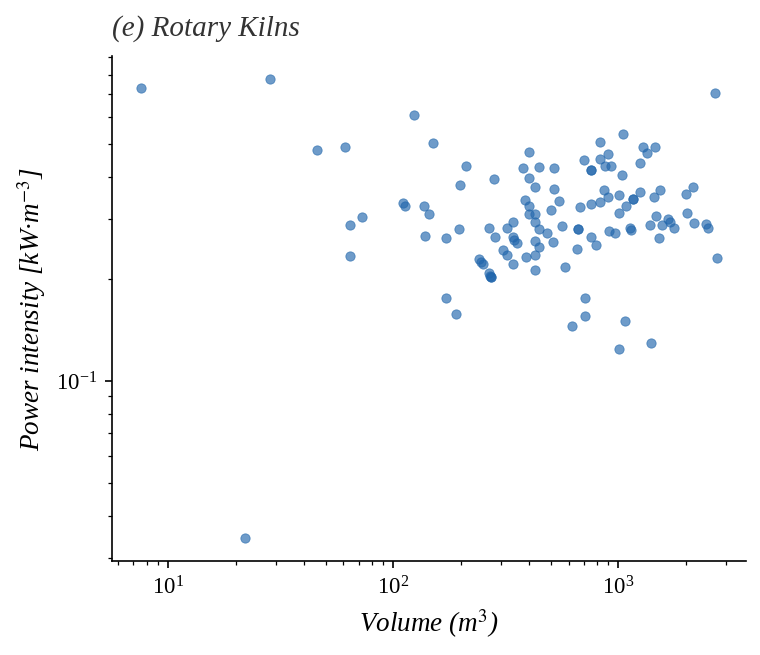

In [7]:
RK_STYLE = {"color": "#2166AC", "marker": "o"}

print("generating Figure S2e")
fig, ax = plt.subplots(figsize=(5.2, 4.5))

ax.scatter(rotary_kilns_raw["Volume_m³"],
           rotary_kilns_raw["PowerToCapacity_kW·m⁻³"],
           color=RK_STYLE["color"], marker=RK_STYLE["marker"],
           s=20, alpha=0.65, edgecolors=RK_STYLE["color"],
           linewidths=0.4, zorder=2)

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Volume (m$^{3}$)", style="italic", fontsize=13)
ax.set_ylabel("Power intensity [kW·m$^{-3}$]", style="italic", fontsize=13)
ax.tick_params(axis="both", labelsize=11)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.set_title("(e) Rotary Kilns", fontsize=14, color="#333333",
             style="italic", pad=10, loc="left")

plt.tight_layout()
plt.show()

## ***5.2. Rotary Kilns: Outlier Screening***

### ***5.2.1 Tukey 1.5 x IQR rule on log(P/V)***

Tukey's fences are the cut-offs that define an outlier in a box plot. Let Q1 and Q3
be the 25th and 75th percentiles of a variable and IQR = Q3 − Q1 the interquartile
range. The fences are

    lower fence = Q1 − 1.5 × IQR        upper fence = Q3 + 1.5 × IQR

and any observation falling outside them is flagged. The 1.5 multiplier is Tukey's
convention: for normally distributed data the fences sit at roughly ±2.7 standard
deviations, so about 0.7% of a clean sample is flagged by chance. The rule uses
percentiles rather than the mean and standard deviation, so the cut-offs are not
themselves dragged outward by the extreme values they are meant to detect.

The rule is applied here to log10(P/V), consistent with the lognormal distribution
of power intensity. Capacity itself is not screened: an unusually small or large
kiln is a legitimate part of the capacity range, and excluding it would narrow the
range over which size independence is claimed. Only kilns whose power intensity is
atypical are removed.

In [8]:
### Table S5a — Tukey fences and the observations they exclude ###

outlier_mask_rk, fence_table_rk = flag_log_space_outliers(
    rotary_kilns_raw, ["log(PowerToCapacity)"], k=1.5
)

# Threshold values, used by the screening figure and the exclusion table below.
fx = fence_table_rk.set_index("Variable")
lo = fx.loc["log(PowerToCapacity)", "Lower fence"]
hi = fx.loc["log(PowerToCapacity)", "Upper fence"]

print("Tukey fences (1.5 × IQR, log10 space):")
display(fence_table_rk)

outliers_iqr_rk = rotary_kilns_raw[outlier_mask_rk].copy()

table_S5_rk = pd.DataFrame({
    "Device": "Rotary Kilns",
    "Entry No. in database": outliers_iqr_rk["Entry_No."].values,
    "Volume (m³)": outliers_iqr_rk["Volume_m³"].values,
    "Power To Capacity (kW·m⁻³)": outliers_iqr_rk["PowerToCapacity_kW·m⁻³"].values,
    "Log (Capacity)": outliers_iqr_rk["log(Capacity)"].values,
    "Log (Power To Capacity)": outliers_iqr_rk["log(PowerToCapacity)"].values,
    "Q1 − 1.5·IQR": lo,
    "Q3 + 1.5·IQR": hi,
})
table_S5_rk["Below lower threshold"] = table_S5_rk["Log (Power To Capacity)"] < lo
table_S5_rk["Above upper threshold"] = table_S5_rk["Log (Power To Capacity)"] > hi
table_S5_rk = table_S5_rk.sort_values("Volume (m³)").reset_index(drop=True)

print(f"\nExcluded: {len(table_S5_rk)} of {len(rotary_kilns_raw)} records "
      f"({100 * len(table_S5_rk) / len(rotary_kilns_raw):.1f}%)")

print("\n\ngenerating Table S5b")
table_S5_rk

Tukey fences (1.5 × IQR, log10 space):


,Variable,Q1,Q3,IQR,Lower fence,Upper fence,Flagged (n)
0,log(PowerToCapacity),-0.587,-0.4277,0.1593,-0.826,-0.1887,7



Excluded: 7 of 120 records (5.8%)


generating Table S5b


,Device,Entry No. in database,Volume (m³),Power To Capacity (kW·m⁻³),Log (Capacity),Log (Power To Capacity),Q1 − 1.5·IQR,Q3 + 1.5·IQR,Below lower threshold,Above upper threshold
0,Rotary Kilns,44,7.54,0.729443,0.877371,-0.137009,-0.826,-0.1887,False,True
1,Rotary Kilns,1,21.87,0.034294,1.339849,-1.464788,-0.826,-0.1887,True,False
2,Rotary Kilns,112,28.28,0.777935,1.451479,-0.109057,-0.826,-0.1887,False,True
3,Rotary Kilns,2,622.04,0.144685,2.793818,-0.839576,-0.826,-0.1887,True,False
4,Rotary Kilns,4,1009.26,0.123853,3.004003,-0.907093,-0.826,-0.1887,True,False
5,Rotary Kilns,6,1395.07,0.129026,3.144596,-0.889323,-0.826,-0.1887,True,False
6,Rotary Kilns,16,2686.07,0.707353,3.429117,-0.150364,-0.826,-0.1887,False,True


### ***5.2.2 Visualization of the IQR screening***

Two figures replace the regression-influence panel used for the other equipment
types. The first is the capacity-class box plot in the style of panel (e) of
`Figure_pooled_capacity_boxplots`; the second shows which observations the fences
exclude across the capacity range.

In [9]:
rotary_kilns_clean = (rotary_kilns_raw[~outlier_mask_rk]
                      .reset_index(drop=True))
rotary_kilns_clean["Capacity Sorted No."] = rotary_kilns_clean.index + 1

print(f"Retained: {len(rotary_kilns_clean)} records")
print(f"Volume range after screening: {rotary_kilns_clean['Volume_m³'].min():.2f} – "
      f"{rotary_kilns_clean['Volume_m³'].max():.2f} m³")
rotary_kilns_clean.head()

Retained: 113 records
Volume range after screening: 45.95 – 2732.21 m³


,Capacity Sorted No.,Entry_No.,Volume_m³,Power_kW,Subtype,PowerToCapacity_kW·m⁻³,log(Capacity),log(PowerToCapacity)
0,1,40,45.95,22.0,Rotary Kiln,0.478781,1.662286,-0.319863
1,2,41,61.08,30.0,Rotary Kiln,0.491159,1.785899,-0.308778
2,3,106,64.34,18.5,Rotary Kiln,0.287535,1.808481,-0.541309
3,4,113,64.34,15.0,Rotary Kiln,0.233136,1.808481,-0.632390
4,5,76,72.39,22.0,Rotary Kiln,0.303909,1.859679,-0.517256


generating Figure S35e


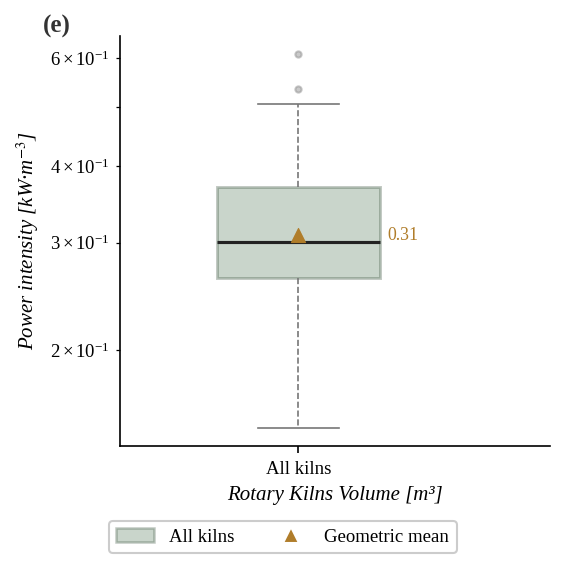

Box plot drawn after outlier removal (n = 113); geometric mean = 0.3084 kW·m⁻³.


In [10]:
from scipy.stats import gmean

print("generating Figure S35e")

CAP_BORDER_MEDIUM = "#1F3A22"
CAP_FACE_MEDIUM   = "#3D6B45"
CAP_ALPHA_MEDIUM  = 0.28

vals_rk = rotary_kilns_clean["PowerToCapacity_kW·m⁻³"].values
vals_rk = vals_rk[vals_rk > 0]

fig, ax = plt.subplots(figsize=(3.9, 3.6))

bp = ax.boxplot(
    [vals_rk], patch_artist=True, widths=0.55, whis=1.5,
    medianprops=dict(color="#222222", linewidth=1.5),
    whiskerprops=dict(linewidth=0.8, linestyle="--", color="#777777"),
    capprops=dict(linewidth=0.8, color="#777777"),
    flierprops=dict(marker="o", markersize=3, alpha=0.45,
                    markerfacecolor="#888888", markeredgecolor="#888888",
                    linewidth=0),
)
for patch in bp["boxes"]:
    patch.set_facecolor(CAP_FACE_MEDIUM)
    patch.set_alpha(CAP_ALPHA_MEDIUM)
    patch.set_edgecolor(CAP_BORDER_MEDIUM)
    patch.set_linewidth(1.4)

gm_box = gmean(vals_rk)
ax.scatter(1, gm_box, color=GM_MARKER_COLOR, marker="^", s=46, zorder=4,
           edgecolors=GM_MARKER_COLOR, linewidths=0.5)
ax.annotate(f"{gm_box:.2f}", xy=(1.30, gm_box), ha="left", va="center",
            fontsize=8.5, color=GM_MARKER_COLOR,
            bbox=dict(facecolor="white", edgecolor="none", pad=1.5), zorder=5)

ax.set_yscale("log")
ax.set_xticks([1]); ax.set_xticklabels(["All kilns"], fontsize=9)
ax.set_xlabel("Rotary Kilns Volume [m³]", style="italic", fontsize=10)
ax.set_ylabel("Power intensity [kW·m$^{-3}$]", style="italic", fontsize=10)
ax.tick_params(axis="both", labelsize=9)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.set_xlim(0.4, 1.85)
ax.annotate("(e)", xy=(-0.18, 1.05), xycoords="axes fraction",
            ha="left", va="top", fontsize=12, fontweight="bold", color="#333333")

legend_els = [
    Patch(facecolor=CAP_FACE_MEDIUM, alpha=CAP_ALPHA_MEDIUM,
          edgecolor=CAP_BORDER_MEDIUM, linewidth=1.2, label="All kilns"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor=GM_MARKER_COLOR,
           markersize=8, label="Geometric mean"),
]
fig.legend(handles=legend_els, loc="lower center", ncol=2, fontsize=9,
           frameon=True, facecolor="white", edgecolor="#cccccc",
           bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
plt.show()

print(f"Box plot drawn after outlier removal (n = {len(vals_rk)}); "
      f"geometric mean = {gm_box:.4f} kW·m⁻³.")

generating Figure S18

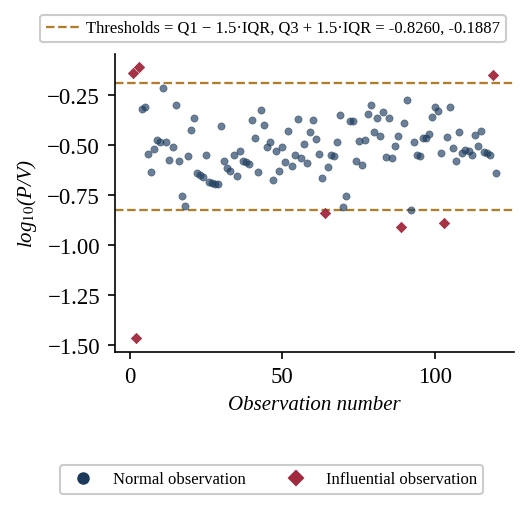

In [11]:
print("generating Figure S18")


obs_rk = np.arange(1, len(rotary_kilns_raw) + 1)
y_obs  = rotary_kilns_raw["log(PowerToCapacity)"].values
normal_mask = ~outlier_mask_rk

THRESH_COLOR = "#B07D2A"

fig, ax = plt.subplots(figsize=(3.75, 3.0))

ax.scatter(obs_rk[normal_mask], y_obs[normal_mask],
           color=OBS_COLOR, alpha=0.65, s=12, linewidths=0.3,
           edgecolors=OBS_COLOR, zorder=2)
ax.scatter(obs_rk[outlier_mask_rk], y_obs[outlier_mask_rk],
           color=REMOVED_PT_COLOR, alpha=0.95, s=12, marker="D",
           linewidths=0.4, edgecolors=REMOVED_PT_COLOR, zorder=3)

for tv in (lo, hi):
    ax.axhline(tv, color=THRESH_COLOR, linewidth=1.1, linestyle="--", zorder=1)

ax.set_ylabel("log$_{10}$(P/V)", style="italic", fontsize=10)
ax.set_xlabel("Observation number", style="italic", fontsize=10)
ax.tick_params(axis="both", labelsize=11)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

th_handle = Line2D([0], [0], color=THRESH_COLOR, linewidth=1.1, linestyle="--",
                   label=f"Thresholds = Q1 − 1.5·IQR, Q3 + 1.5·IQR = {lo:.4f}, {hi:.4f}")
leg = ax.legend(handles=[th_handle], fontsize=8, frameon=True,
                facecolor="white", edgecolor="#cccccc",
                loc="lower right", bbox_to_anchor=(1.0, 1.01),
                handletextpad=0.4, borderpad=0.35)
leg.set_zorder(5)

legend_els = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=OBS_COLOR,
           markeredgecolor=OBS_COLOR, markersize=5, label="Normal observation"),
    Line2D([0], [0], marker="D", color="w", markerfacecolor=REMOVED_PT_COLOR,
           markeredgecolor=REMOVED_PT_COLOR, markersize=5, label="Influential observation"),
]
fig.legend(handles=legend_els, loc="lower center", ncol=2, fontsize=8,
           frameon=True, facecolor="white", edgecolor="#cccccc",
           bbox_to_anchor=(0.5, -0.14))

plt.tight_layout()
plt.show()

### ***5.2.3 Capacity coverage of the screened dataset***

Vendor listings concentrate in mid-range commercial sizes, with the very small and
very large tails thinly sampled. The histogram is binned by the Freedman–Diaconis
rule applied to log₁₀(V), so bins are of equal width in log space. This is the
figure the capacity-coverage entry of Table S26 is read from.

generating Figure S45e


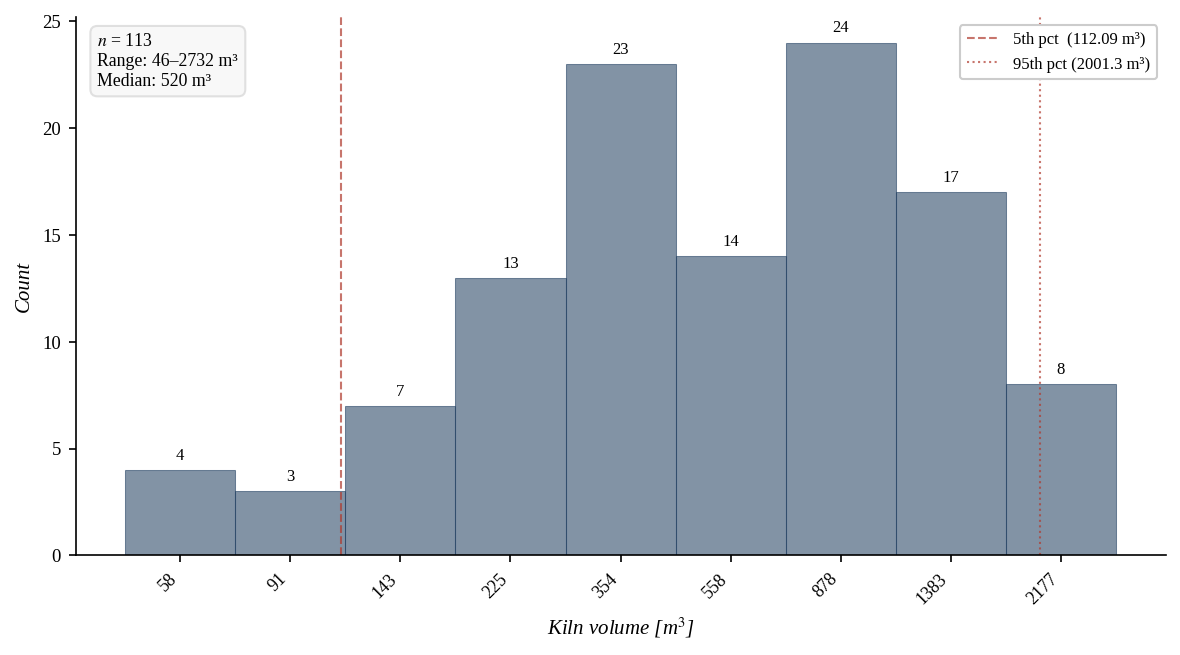

=== Capacity distribution summary — Rotary Kilns (post-outlier removal) ===
  n                : 113
  Min              : 45.9500 m³
  Max              : 2732.21 m³
  Median           : 519.550 m³
  5th percentile   : 112.0852 m³
  95th percentile  : 2001.28 m³
  Peak bin (mode)  : ~878 m³  (n = 24)
  FD bins used     : 9


In [12]:
print("generating Figure S45e")

## Capacity Size Distribution — Vendor Dataset Coverage (after outlier removal)
# Shows that vendor listings are concentrated in mid-range commercial sizes,
# with tails (very small and very large equipment) thinly sampled.

# ── 1. Data preparation ──────────────────────────────────────────────────────
volumes = rotary_kilns_clean["Volume_m³"].dropna().values
log_volumes = np.log10(volumes)

# ── 2. Bin width: Freedman–Diaconis on log10(V) ──────────────────────────────
# Applied on log scale to respect lognormal distribution of capacity data.
# Produces bins of equal width in log space → equal width on log x-axis.
n_bins = freedman_diaconis_bins(log_volumes)
bin_edges_log = np.linspace(log_volumes.min(), log_volumes.max(), n_bins + 1)
bin_edges_raw = 10 ** bin_edges_log  # back-transform for x-tick labels

counts, _ = np.histogram(log_volumes, bins=bin_edges_log)

# ── 3. Bin centers and labels ─────────────────────────────────────────────────
bin_centers_log = 0.5 * (bin_edges_log[:-1] + bin_edges_log[1:])
bin_centers_raw = 10 ** bin_centers_log

# Format x-tick labels as rounded raw volumes (m³)
def _fmt_vol(v):
    if v < 0.01:   return f"{v:.3f}"
    elif v < 1:    return f"{v:.2f}"
    elif v < 10:   return f"{v:.1f}"
    else:          return f"{v:.0f}"

tick_labels = [_fmt_vol(v) for v in bin_centers_raw]

# ── 4. Identify peak bin (mode) for annotation ───────────────────────────────
peak_idx   = np.argmax(counts)
peak_count = counts[peak_idx]
peak_vol   = bin_centers_raw[peak_idx]

# ── 5. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))

bars = ax.bar(
    bin_centers_log,
    counts,
    width=np.diff(bin_edges_log),
    color=OBS_COLOR,
    alpha=0.55,
    edgecolor=OBS_COLOR,
    linewidth=0.5,
    align="center",
)

# Count labels on top of each bar
for bar, count in zip(bars, counts):
    if count > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            str(count),
            ha="center", va="bottom",
            fontsize=8, color="black",
        )

# Vertical dashed lines at dataset tails (5th and 95th percentile of log V)
p5  = np.percentile(log_volumes, 5)
p95 = np.percentile(log_volumes, 95)
ax.axvline(p5,  color="#B03A2E", linewidth=1.0, linestyle="--", alpha=0.7,
           label=f"5th pct  ({10**p5:.2f} m³)")
ax.axvline(p95, color="#B03A2E", linewidth=1.0, linestyle=":",  alpha=0.7,
           label=f"95th pct ({10**p95:.1f} m³)")

# ── 6. Axes formatting ────────────────────────────────────────────────────────
ax.set_xticks(bin_centers_log)
ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8.5)
ax.set_xlabel("Kiln volume [m$^3$]", style="italic", fontsize=10)
ax.set_ylabel("Count", style="italic", fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(fontsize=8, frameon=True, facecolor="white",
          edgecolor="#cccccc", loc="upper right")

# Summary stats text box
n_total = len(volumes)
v_min   = volumes.min()
v_max   = volumes.max()
v_med   = np.median(volumes)
ax.text(
    0.02, 0.97,
    f"$n$ = {n_total}\n"
    f"Range: {_fmt_vol(v_min)}–{_fmt_vol(v_max)} m³\n"
    f"Median: {_fmt_vol(v_med)} m³",
    transform=ax.transAxes,
    fontsize=8.5, color="black",
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#f8f8f8",
              edgecolor="#dddddd", alpha=0.9),
)

plt.tight_layout()
plt.show()

# ── 7. Numerical summary ──────────────────────────────────────────────────────
print("=== Capacity distribution summary — Rotary Kilns (post-outlier removal) ===")
print(f"  n                : {n_total}")
print(f"  Min              : {v_min:.4f} m³")
print(f"  Max              : {v_max:.2f} m³")
print(f"  Median           : {v_med:.3f} m³")
print(f"  5th percentile   : {10**p5:.4f} m³")
print(f"  95th percentile  : {10**p95:.2f} m³")
print(f"  Peak bin (mode)  : ~{_fmt_vol(peak_vol)} m³  (n = {peak_count})")
print(f"  FD bins used     : {n_bins}")

## ***5.3. Rotary Kilns: Test for Size Dependence***

### ***5.3.1 Model selection: fit statistics and nested comparison***

Two polynomial models are *nested* when the simpler one is the special case of the
more complex one obtained by setting its extra coefficients to zero. A constant is
a degree-1 polynomial with a₁ = 0; a degree-1 polynomial is a degree-2 polynomial
with a₂ = 0. The nested F-test asks whether the extra coefficients buy enough
reduction in residual sum of squares (RSS) to justify the degrees of freedom they
cost:

    F = [(RSS_simple − RSS_complex) / (df_simple − df_complex)] / (RSS_complex / df_complex)

Under the null hypothesis that the extra coefficients are all zero, F follows an
F distribution with (df_simple − df_complex, df_complex) degrees of freedom. A
large p-value means the added order does not improve the fit beyond what additional
free parameters would achieve by chance, and the simpler model is retained.

This differs from the F-statistic printed in a standard OLS summary, which tests
the fitted model against an intercept-only null rather than against the next-lower
polynomial order. Only the nested form answers the order-selection question.

Degree 0 is the constant model, i.e. a single geometric mean in log space. Each
order is tested against the next lower order, and AIC and BIC are reported on the
same fits as independent, likelihood-based criteria.

In [13]:
### Table S2 (unscreened, degrees 1–3) and the nested comparison (screened, degrees 0–3) ###

def si_model_selection_table(x, y, device, degrees=(1, 2, 3)):
    """Columns matching SI Table S2: R2, R2-adj, RMSE, AIC, BIC, overall F, Sig-F."""
    rows = []
    for deg in degrees:
        X = np.vander(x, deg + 1, increasing=True)
        m = sm.OLS(y, X).fit()
        rows.append({
            "": device,
            "Degree": deg,
            "R2": m.rsquared,
            "R2-adj": m.rsquared_adj,
            "RMSE": float(np.sqrt(np.mean(m.resid ** 2))),
            "AIC": m.aic,
            "BIC": m.bic,
            "F-stat": m.fvalue,
            "Significance-F": m.f_pvalue,
        })
    return pd.DataFrame(rows)


# ---- Table S2: fit statistics on the unscreened dataset --------------------
table_S2_rk = si_model_selection_table(
    rotary_kilns_raw["log(Capacity)"].values,
    rotary_kilns_raw["log(PowerToCapacity)"].values,
    device="Rotary Kilns",
)

print("generating Table S2")

print("fit statistics, unscreened dataset (n = %d). "
      "F-stat is the overall model test against an intercept-only null."
      % len(rotary_kilns_raw))
display(table_S2_rk)

# ---- Nested comparison: screened dataset, degree 0 included ----------------
x_rk = rotary_kilns_clean["log(Capacity)"].values
y_rk = rotary_kilns_clean["log(PowerToCapacity)"].values

model_selection_rk, fits_rk = nested_polynomial_comparison(x_rk, y_rk, max_degree=3)

nested_only_rk = model_selection_rk[["Degree", "k (params)",
                                     "F vs degree-1 lower", "p (nested F)"]]

print("\nNested comparison — screened dataset (n = %d). Each order is tested "
      "against the next lower order; degree 0 is the constant model."
      % len(x_rk))
nested_only_rk

generating Table S2
fit statistics, unscreened dataset (n = 120). F-stat is the overall model test against an intercept-only null.


,,Degree,R2,R2-adj,RMSE,AIC,BIC,F-stat,Significance-F
0,Rotary Kilns,1,0.003670,-0.004773,0.168439,-82.937808,-77.362825,0.434693,0.510980
1,Rotary Kilns,2,0.025582,0.008925,0.166577,-83.606303,-75.243827,1.535813,0.219589
2,Rotary Kilns,3,0.028218,0.003086,0.166351,-81.931459,-70.781492,1.122794,0.342852



Nested comparison — screened dataset (n = 113). Each order is tested against the next lower order; degree 0 is the constant model.


,Degree,k (params),F vs degree-1 lower,p (nested F)
0,0,1,NaN,NaN
1,1,2,0.9968,0.3203
2,2,3,3.1284,0.0797
3,3,4,8.5497,0.0042


### ***5.3.2 Regression coefficients for degrees 1–3***

Coefficients, t-statistics, p-values and 95% confidence intervals for polynomial
orders 1 to 3, fitted on the unscreened dataset. This is the rotary kiln entry for
SI Table S3 and matches the basis used for the other equipment types.

An order is eligible for selection only if every one of its coefficients has a 95%
confidence interval excluding zero. An order carrying a coefficient consistent with
zero is not adopted, since that term contributes no resolvable effect. The one
exception is degree 1 when scaling is visually evident, where a slope whose interval
straddles zero indicates weak rather than absent scaling.

In [14]:
### Table S3 — regression coefficients, degrees 1–3 (unscreened) ###

print("generating Table S3")

coeff_table_rk = polynomial_coefficient_table(
    rotary_kilns_raw["log(Capacity)"].values,
    rotary_kilns_raw["log(PowerToCapacity)"].values,
    device="Rotary Kilns",
    degrees=(1, 2, 3),
)
coeff_table_rk

generating Table S3


,Device,Degree,Term,Coefficient,T-stat,p-value,CI lower,CI upper,CI contains zero,Eligible
0,Rotary Kilns,1,Intercept,-0.579437,-6.186694,9.153002e-09,-0.764907,-0.393968,False,False
1,Rotary Kilns,1,x^1,0.022605,0.659312,5.109798e-01,-0.045290,0.090499,True,False
2,Rotary Kilns,2,Intercept,-0.147223,-0.521629,6.029145e-01,-0.706178,0.411732,True,False
3,Rotary Kilns,2,x^1,-0.344997,-1.505375,1.349227e-01,-0.798870,0.108876,True,False
4,Rotary Kilns,2,x^2,0.074791,1.622013,1.074923e-01,-0.016527,0.166109,True,False
5,Rotary Kilns,3,Intercept,0.212599,0.303254,7.622391e-01,-1.175934,1.601132,True,False
6,Rotary Kilns,3,x^1,-0.885072,-0.894261,3.730341e-01,-2.845346,1.075202,True,False
7,Rotary Kilns,3,x^2,0.323667,0.725683,4.694946e-01,-0.559726,1.207060,True,False
8,Rotary Kilns,3,x^3,-0.036100,-0.561021,5.758655e-01,-0.163548,0.091348,True,False


### ***5.3.3 HC3-robust test of the linear slope***

The degree-1 slope is tested against zero using a heteroscedasticity-consistent
(HC3) standard error, matching the inference convention used for the other
equipment types.

In [15]:
X_rk = np.vander(x_rk, 2, increasing=True)
ols_rk = sm.OLS(y_rk, X_rk).fit()
robust_rk = ols_rk.get_robustcov_results(cov_type="HC3")

ci = robust_rk.conf_int()[1]
print("=== Degree-1 log-log model with HC3 standard errors ===")
print(f"  Intercept a0 : {robust_rk.params[0]:+.4f}")
print(f"  Slope     a1 : {robust_rk.params[1]:+.4f}   "
      f"95% CI [{ci[0]:+.4f}, {ci[1]:+.4f}]")
print(f"  HC3 p-value  : {robust_rk.pvalues[1]:.4f}")
print(f"  R²_adj       : {ols_rk.rsquared_adj:.4f}")
print()
print("  Slope indistinguishable from zero." if robust_rk.pvalues[1] >= 0.05
      else "  Slope differs from zero.")
print(robust_rk.summary())

=== Degree-1 log-log model with HC3 standard errors ===
  Intercept a0 : -0.5915
  Slope     a1 : +0.0297   95% CI [-0.0362, +0.0956]
  HC3 p-value  : 0.3745
  R²_adj       : -0.0000

  Slope indistinguishable from zero.
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.7952
Date:                Mon, 20 Jul 2026   Prob (F-statistic):              0.374
Time:                        15:00:30   Log-Likelihood:                 78.126
No. Observations:                 113   AIC:                            -152.3
Df Residuals:                     111   BIC:                            -146.8
Df Model:                           1                                         
Covariance Type:                  HC3                               

### ***5.3.4 Constant model before and after outlier removal***

The band is ±RMSE in log space, matching the scaling figures for the other
equipment types. For a constant model the residuals are the deviations from the
log₁₀ mean, so RMSE is the standard deviation of log₁₀(P/V) about that mean — the
same quantity, computed the same way (`sqrt(mean(resid²))`). The sample standard
deviation used for the geometric standard deviation and the prediction interval in
§5.5 carries the ddof = 1 correction and is denoted `s`; the two differ only by
the factor √((n−1)/n) and are reported side by side below.

generating Figure S34


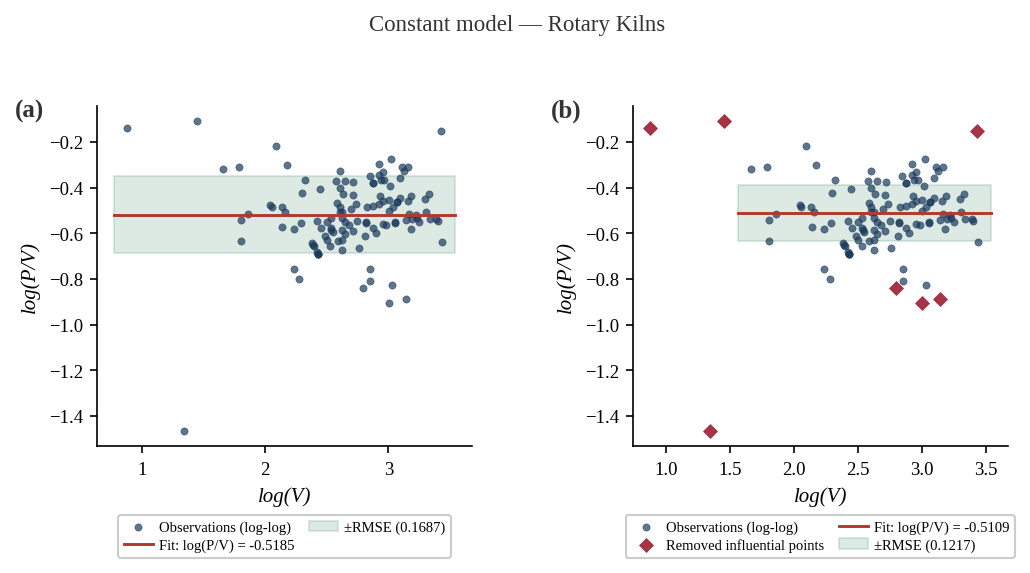

Before removal : log10(P/V) = -0.5185  (GM = 0.3030 kW·m⁻³), RMSE = 0.1687, s = 0.1695, GSD = 1.4773
After removal  : log10(P/V) = -0.5109  (GM = 0.3084 kW·m⁻³), RMSE = 0.1217, s = 0.1223, GSD = 1.3252


In [16]:
print("generating Figure S34")

def _draw_constant_panel(ax, x, y, mean_val, label, removed_pts=None):
    """One log-space panel: constant model line, ±RMSE band, scatter.

    RMSE is computed as sqrt(mean(resid**2)) about the constant model, matching
    the definition used for the regression fits of the other equipment types.
    """
    resid = y - mean_val
    rmse = float(np.sqrt(np.mean(resid ** 2)))

    xg = np.linspace(x.min() - 0.1, x.max() + 0.1, 200)

    ax.fill_between(xg, mean_val - rmse, mean_val + rmse,
                    color=RMSE_BAND_COLOR, alpha=0.22, zorder=1,
                    label=f"±RMSE ({rmse:.4f})")
    ax.plot(xg, np.full_like(xg, mean_val), color=FIT_LINE_COLOR, linewidth=1.4,
            zorder=3, label=f"Fit: log(P/V) = {mean_val:.4f}")
    ax.scatter(x, y, color=OBS_COLOR, alpha=0.70, s=12, linewidths=0.3,
               edgecolors=OBS_COLOR, zorder=2, label="Observations (log-log)")
    if removed_pts is not None and len(removed_pts[0]) > 0:
        ax.scatter(removed_pts[0], removed_pts[1], color=REMOVED_PT_COLOR,
                   alpha=0.95, s=22, marker="D", linewidths=0.4,
                   edgecolors=REMOVED_PT_COLOR, zorder=4,
                   label="Removed influential points")


    handles, labels = ax.get_legend_handles_labels()

    order_keys = ["Observations", "Removed", "Fit:", "±RMSE"]

    def sort_key(lbl):
        for i, k in enumerate(order_keys):
            if k in lbl:
                return i
        return 99

    handles, labels = zip(*sorted(zip(handles, labels), key=lambda p: sort_key(p[1])))
    ax.legend(handles=handles, labels=labels, fontsize=7, frameon=True,
              facecolor="white", edgecolor="#cccccc",
              loc="upper center", bbox_to_anchor=(0.5, -0.18),
              ncol=2, handletextpad=0.4, borderpad=0.4,
              labelspacing=0.3, columnspacing=1.0)

    ax.set_xlabel("log(V)", style="italic", fontsize=10)
    ax.set_ylabel("log(P/V)", style="italic", fontsize=10)
    ax.tick_params(axis="both", labelsize=9)
    ax.annotate(label, xy=(-0.22, 1.02), xycoords="axes fraction",
                ha="left", va="top", fontsize=12, fontweight="bold", color="#333333")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    return rmse


x_all = rotary_kilns_raw["log(Capacity)"].values
y_all = rotary_kilns_raw["log(PowerToCapacity)"].values

mean_before = y_all.mean()
mean_rk     = y_rk.mean()
s_rk        = y_rk.std(ddof=1)
gm_rk       = 10 ** mean_rk

removed_rk = rotary_kilns_raw[outlier_mask_rk]
removed_pts_rk = (removed_rk["log(Capacity)"].values,
                  removed_rk["log(PowerToCapacity)"].values)

fig, axes = plt.subplots(1, 2, figsize=(7.0, 4.0))

rmse_before = _draw_constant_panel(axes[0], x_all, y_all, mean_before, "(a)")
rmse_rk     = _draw_constant_panel(axes[1], x_rk, y_rk, mean_rk, "(b)",
                                   removed_pts=removed_pts_rk)

fig.suptitle("Constant model — Rotary Kilns", fontsize=11, color="#333333", y=1.02)
plt.tight_layout(w_pad=3.5)
plt.subplots_adjust(bottom=0.30, left=0.10)
plt.show()

print(f"Before removal : log10(P/V) = {mean_before:.4f}  "
      f"(GM = {10 ** mean_before:.4f} kW·m⁻³), RMSE = {rmse_before:.4f}, "
      f"s = {y_all.std(ddof=1):.4f}, GSD = {10 ** y_all.std(ddof=1):.4f}")
print(f"After removal  : log10(P/V) = {mean_rk:.4f}  "
      f"(GM = {gm_rk:.4f} kW·m⁻³), RMSE = {rmse_rk:.4f}, "
      f"s = {s_rk:.4f}, GSD = {10 ** s_rk:.4f}")

generating Figure 1e


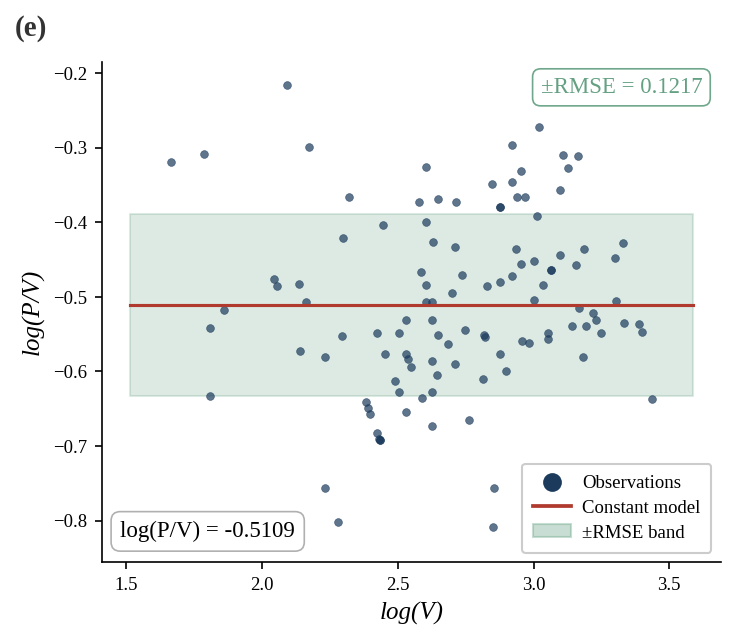

In [17]:
print("generating Figure 1e")
fig, ax = plt.subplots(figsize=(5.0, 4.4))

xg = np.linspace(x_rk.min() - 0.15, x_rk.max() + 0.15, 300)
ax.fill_between(xg, mean_rk - rmse_rk, mean_rk + rmse_rk,
                color=RMSE_BAND_COLOR, alpha=0.22, zorder=1)
ax.plot(xg, np.full_like(xg, mean_rk), color=FIT_LINE_COLOR, linewidth=1.5, zorder=3)
ax.scatter(x_rk, y_rk, color=OBS_COLOR, alpha=0.70, s=14,
           linewidths=0.3, edgecolors=OBS_COLOR, zorder=2)

ax.text(0.97, 0.97, f"±RMSE = {rmse_rk:.4f}",
        transform=ax.transAxes, fontsize=11,
        va="top", ha="right", color=RMSE_BAND_COLOR,
        bbox=dict(facecolor="white", edgecolor=RMSE_BAND_COLOR,
                  alpha=0.92, boxstyle="round,pad=0.35", linewidth=0.8))

ax.text(0.03, 0.04, f"log(P/V) = {mean_rk:.4f}",
        transform=ax.transAxes, fontsize=11,
        va="bottom", ha="left",
        bbox=dict(facecolor="white", edgecolor="#aaaaaa",
                  alpha=0.92, boxstyle="round,pad=0.4", linewidth=0.8))

ax.set_xlabel("log(V)", style="italic", fontsize=12)
ax.set_ylabel("log(P/V)", style="italic", fontsize=12)
ax.tick_params(axis="both", labelsize=9)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.annotate("(e)", xy=(-0.14, 1.04), xycoords="axes fraction",
            ha="left", va="bottom", fontsize=14, fontweight="bold", color="#333333")

legend_els = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=OBS_COLOR,
           markeredgecolor=OBS_COLOR, markersize=8, label="Observations"),
    Line2D([0], [0], color=FIT_LINE_COLOR, linewidth=1.8, label="Constant model"),
    Patch(facecolor=RMSE_BAND_COLOR, alpha=0.35, edgecolor=RMSE_BAND_COLOR,
          label="±RMSE band"),
]
ax.legend(handles=legend_els, fontsize=9, frameon=True, facecolor="white",
          edgecolor="#cccccc", framealpha=1.0, loc="lower right",
          handletextpad=0.6, borderpad=0.6, labelspacing=0.4)

plt.tight_layout()
plt.show()

## ***5.4. Rotary Kilns: Assumption Checks***

Selecting a constant model does not remove the need for these checks. The geometric
mean is reported with a geometric standard deviation, a confidence interval and a
prediction interval, and all three presuppose that log₁₀(P/V) is normally
distributed with dispersion that does not vary with capacity. Normality is tested
on the deviations from the log₁₀ mean; constancy of dispersion is tested by
Breusch–Pagan against log₁₀ capacity.

Because the fitted value of a constant model is invariant, the left panel plots
residuals against log₁₀ capacity rather than against fitted values, which is also
the covariate the Breusch–Pagan test uses.

generating Figure S44


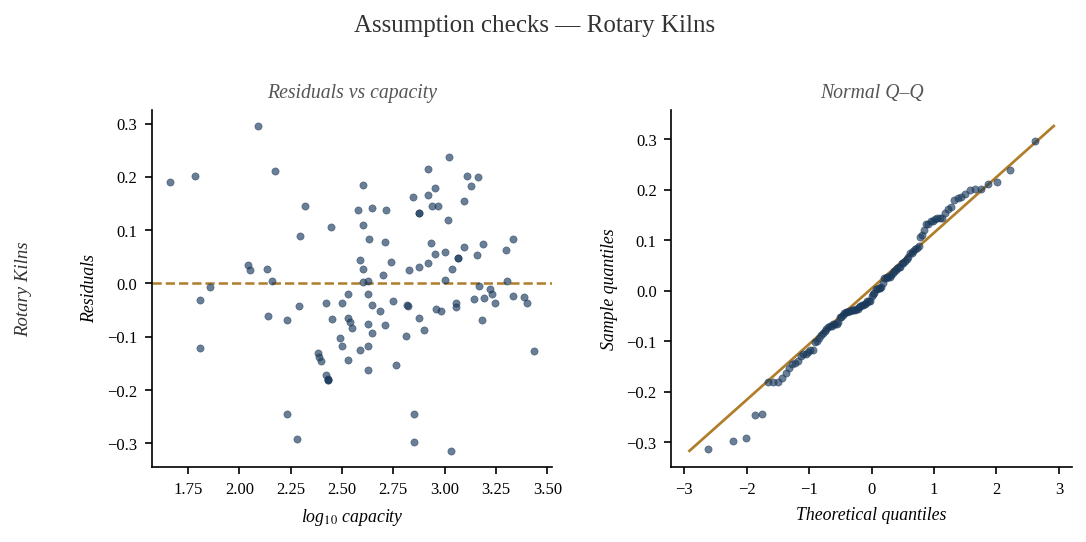

Kolmogorov–Smirnov (normality): statistic = 0.0596, p = 0.7941
Breusch–Pagan (homoscedasticity): LM = 2.6836, p = 0.1014


In [18]:
print("generating Figure S44")
lg_rk = np.log10(rotary_kilns_clean["PowerToCapacity_kW·m⁻³"].values)
dev_rk = lg_rk - lg_rk.mean()
n_rk = len(lg_rk)

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.6))

# ---- (left) residuals vs capacity ------------------------------------------
# For a constant model the fitted value is invariant, so residuals are plotted
# against log10 capacity: this is the covariate the Breusch-Pagan test uses.
ax_resid = axes[0]
ax_resid.scatter(rotary_kilns_clean["log(Capacity)"], dev_rk,
                 color=OBS_COLOR, alpha=0.65, s=12,
                 linewidths=0.3, edgecolors=OBS_COLOR, zorder=2)
ax_resid.axhline(0, color=REF_LINE_COLOR, linewidth=1.2, linestyle="--", zorder=1)
ax_resid.set_xlabel("log$_{10}$ capacity", style="italic", fontsize=8.5)
ax_resid.set_ylabel("Residuals", style="italic", fontsize=8.5)
ax_resid.tick_params(axis="both", labelsize=8)
ax_resid.spines["top"].set_visible(False); ax_resid.spines["right"].set_visible(False)

# ---- (right) normal Q-Q ----------------------------------------------------
ax_qq = axes[1]
resid_sorted = np.sort(dev_rk)
theoretical_q = stats.norm.ppf((np.arange(1, n_rk + 1) - 0.5) / n_rk)
ax_qq.scatter(theoretical_q, resid_sorted, color=OBS_COLOR, alpha=0.65, s=12,
              linewidths=0.3, edgecolors=OBS_COLOR, zorder=2)
q25_t, q75_t = np.percentile(theoretical_q, [25, 75])
q25_s, q75_s = np.percentile(resid_sorted, [25, 75])
slope_qq = (q75_s - q25_s) / (q75_t - q25_t)
intercept_qq = q25_s - slope_qq * q25_t
xline = np.array([theoretical_q.min() - 0.3, theoretical_q.max() + 0.3])
ax_qq.plot(xline, intercept_qq + slope_qq * xline,
           color=REF_LINE_COLOR, linewidth=1.3, zorder=1)
ax_qq.set_xlabel("Theoretical quantiles", style="italic", fontsize=8.5)
ax_qq.set_ylabel("Sample quantiles", style="italic", fontsize=8.5)
ax_qq.tick_params(axis="both", labelsize=8)
ax_qq.spines["top"].set_visible(False); ax_qq.spines["right"].set_visible(False)

ax_resid.annotate("Rotary Kilns", xy=(-0.32, 0.5), xycoords="axes fraction",
                  ha="center", va="center", rotation=90,
                  fontsize=9, color="#333333", style="italic")

fig.suptitle("Assumption checks — Rotary Kilns", fontsize=12, color="#333333", y=0.995)
ax_resid.set_title("Residuals vs capacity", fontsize=9.5, color="#555555",
                   style="italic", pad=6)
ax_qq.set_title("Normal Q–Q", fontsize=9.5, color="#555555", style="italic", pad=6)

plt.tight_layout(h_pad=2.0, w_pad=2.0)
plt.subplots_adjust(left=0.16)
plt.show()

if n_rk < 50:
    stat_n, p_n = stats.shapiro(dev_rk)
    test_name = "Shapiro–Wilk"
else:
    stat_n, p_n = stats.kstest(dev_rk, "norm",
                              args=(dev_rk.mean(), dev_rk.std(ddof=1)))
    test_name = "Kolmogorov–Smirnov"

bp_stat, bp_p, _, _ = het_breuschpagan(
    dev_rk, np.vander(rotary_kilns_clean["log(Capacity)"].values, 2, increasing=True)
)

print(f"{test_name} (normality): statistic = {stat_n:.4f}, p = {p_n:.4g}")
print(f"Breusch–Pagan (homoscedasticity): LM = {bp_stat:.4f}, p = {bp_p:.4g}")

In [19]:
print("generating Table S24\n")


table_S24_rk = pd.DataFrame([
    {"": "Rotary Kilns", "Subtype": "—", "Test": test_name,
     "Diagnostic": "Normality", "Statistic": round(float(stat_n), 4),
     "p-value": round(float(p_n), 4),
     "Result": "Not rejected" if p_n >= 0.05 else "Rejected"},
    {"": "Rotary Kilns", "Subtype": "—", "Test": "Breusch–Pagan",
     "Diagnostic": "Homoscedasticity", "Statistic": round(float(bp_stat), 4),
     "p-value": round(float(bp_p), 4),
     "Result": "Not rejected" if bp_p >= 0.05 else "Rejected"},
])
table_S24_rk

generating Table S24



,,Subtype,Test,Diagnostic,Statistic,p-value,Result
0,Rotary Kilns,—,Kolmogorov–Smirnov,Normality,0.0596,0.7941,Not rejected
1,Rotary Kilns,—,Breusch–Pagan,Homoscedasticity,2.6836,0.1014,Not rejected


## ***5.5. Rotary Kilns: Summary***

The reported estimate is the geometric mean of installed drum-drive power intensity
over the screened dataset. Dispersion is reported as `s`, the standard deviation of
log₁₀(P/V), consistent with the dispersion symbol used for the regression-based
equipment types. For rotary kilns `s` is the standard deviation of the log₁₀ values
themselves rather than a regression RMSE, because no regression is fitted.

In [20]:
### Consolidated summary — dataset, screening, adopted model and dispersion ###

constant_model_rk = constant_model_summary(
    rotary_kilns_clean["PowerToCapacity_kW·m⁻³"], "Rotary Kilns"
)
cm = constant_model_rk.iloc[0]

summary_rk = pd.DataFrame([{
    "Equipment": "Rotary Kilns",
    "n (raw)": len(rotary_kilns_raw),
    "n (screened)": int(cm["n"]),
    "Excluded": int(outlier_mask_rk.sum()),
    "Capacity range, raw [m³]": (
        f"{rotary_kilns_raw['Volume_m³'].min():.2f} – "
        f"{rotary_kilns_raw['Volume_m³'].max():.2f}"
    ),
    "Capacity range, screened [m³]": (
        f"{rotary_kilns_clean['Volume_m³'].min():.2f} – "
        f"{rotary_kilns_clean['Volume_m³'].max():.2f}"
    ),
    "Screening rule": "1.5 × IQR on log10(P/V)",
    "Thresholds [log10]": f"{lo:.4f}, {hi:.4f}",
    "Adopted model": "Constant P/V (size-independent)",
    "Slope (degree-1, HC3 p)": f"{robust_rk.params[1]:+.4f} (p = {robust_rk.pvalues[1]:.3f})",
    "Installed GM [kW·m⁻³]": cm["Geometric mean"],
    "s (log10)": cm["s (log10)"],
    "GSD": cm["GSD"],
    "95% CI for GM": cm["95% CI for GM"],
    "95% prediction interval": cm["95% prediction interval"],
    "Smearing factor": cm["Smearing factor"],
    "Normality (p)": round(float(p_n), 4),
    "Breusch–Pagan (p)": round(float(bp_p), 4),
}])

summary_rk.T

,0
Equipment,Rotary Kilns
n (raw),120
n (screened),113
Excluded,7
"Capacity range, raw [m³]",7.54 – 2732.21
"Capacity range, screened [m³]",45.95 – 2732.21
Screening rule,1.5 × IQR on log10(P/V)
Thresholds [log10],"-0.8260, -0.1887"
Adopted model,Constant P/V (size-independent)
"Slope (degree-1, HC3 p)",+0.0297 (p = 0.374)
